In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import savgol_filter
from scipy.stats import spearmanr
from scipy.stats import rankdata
import pingouin as pg
import pandas as pd

In [15]:
long_GRBs = """
GRB080723557	58.369	3.072	1.74E+02	55	8	35.571	158/167	28.1
GRB080804972	24.704	0.256	2.21E+02	13	8	13.585	30/167	73.6
GRB080816503	64.769	1.28	1.26E+02	23	8	12.896	57/167	77.5
GRB080817161	60.289	2.048	3.63E+02	18	8	24.122	107/167	41.5
GRB080825593	20.992	1.216	1.74E+02	29	11	34.897	155/167	28.7
GRB080906212	2.875	0.005	1.27E+02	23	13	25.469	113/167	39.3
GRB080916009	62.977	1.28	6.68E+02	28	8	28.163	125/167	35.5
GRB080925775	31.744	-1.024	1.64E+02	49	10	27.938	124/167	35.8
GRB081009140	41.345	1.344	2.93E+01	60	9	35.347	157/167	28.3
GRB081125496	9.28	0.512	1.66E+02	21	8	10.203	45/167	98
GRB081129161	62.657	-0.128	2.56E+02	26	8	13.57	60/167	73.7
GRB081221681	29.697	3.328	8.69E+01	45	10	35.122	156/167	28.5
GRB081224887	16.448	0.736	4.09E+02	13	10	4.365	19/167	229.1
GRB090102122	26.624	1.536	4.25E+02	11	8	17.386	77/167	57.5
GRB090131090	35.073	3.072	4.66E+01	43	10	23.897	106/167	41.8
GRB090328401	61.697	4.352	6.51E+02	8	8	15.142	67/167	66
GRB090411991	14.336	0.768	1.72E+02	45	8	18.733	83/167	53.4
GRB090424592	14.144	0.512	1.60E+02	4	8	31.979	142/167	31.3
GRB090425377	75.393	3.584	4.35E+01	12	9	11.774	52/167	84.9
GRB090528516	79.041	4.352	2.31E+02	4	8	5.264	23/167	190
GRB090626189	48.897	1.536	1.87E+02	25	9	34.224	152/167	29.2
GRB090718762	23.744	3.392	1.62E+02	8	9	30.407	135/167	32.9
GRB090829672	67.585	10.24	4.70E+02	15	8	13.795	61/167	72.5
GRB090831317	39.424	0	2.56E+02	49	11	34.897	155/167	28.7
GRB200716957	5.312	0.128	4.70E+02	8	10	306.032	136/167	3.3
GRB241228176	19.456	1.6	None	5	8	35.571	158/167	28.1
GRB240619155	36.126	-1	3.24E+02	3	11	25.02	111/167	40				
GRB220527387	10.496	-5	1.22E+02	3	26	8.406	37/167	119"""

In [16]:
short_GRBs = """GRB080723913	0.192	-0.064		4	11	120.016	53/167	8.3
GRB081216531	1.664	-0.192		5	4	49.607	22/200	20.2
GRB090227772	1.28	-0.016		11	9	342.038	152/167	2.9"""

Parse the GRB catalog (copy and pasted from google sheets file)

In [17]:
GRB_catalog = {}
preburst_buffer = 1 #seconds before trigger time (t=0)

for line in long_GRBs.strip().splitlines(): # splits into list of lines, 1 line per GRB
    columns = line.split('\t') # creates a list of tab separated columns 
    GRB_catalog[columns[0]] = {'T90': float(columns[1]), 'T90 start': float(columns[2]), 'QTMVT': float(columns[8]), 'type':'long'}
    
for line in short_GRBs.strip().splitlines():
    columns = line.split('\t')
    GRB_catalog[columns[0]] = {'T90': float(columns[1]), 'T90 start': float(columns[2]), 'QTMVT': float(columns[8]), 'type':'short'}

Define the pulses from Bhat paper: https://arxiv.org/pdf/1109.4064
With theory credit to https://arxiv.org/pdf/1205.0055

Loop through each GRB and find the rise times of each peak

Rise time is measured from the local minimum preceding each peak, to the tip of the peak. Minimum rise time is taken across all the detected pulses per GRB. 

In [24]:
results = []
for GRB_name, parameters in GRB_catalog.items():
    signal = np.load(f'{GRB_name}_signal.npy')
    time = np.load(f'{GRB_name}_time.npy')
    
    T5 = parameters['T90 start']
    T95 = T5+parameters['T90']
    preburst_start = time[1]
    preburst_end = 0-preburst_buffer 
    preburst_mask = (time >= preburst_start) & (time < preburst_end)
    burst_mask = (time>=T5)&(time<=T95)

    ### Finding the Peaks ###
    
    # Calculate window saize for the smoothing filter 
    if parameters['type'] == 'short':
        smoothed_section = parameters['T90']*0.1 # Window ~100ms, this is around the shorter pulse times in short GRBs
    else:
        smoothed_section = 1 # 1 second windows for the long GRBs

    window = max(3, int(smoothed_section/Tbin) )

    # Set any negative values in the background subtracted signal to 0
    signal_positive = np.clip(signal,0,None) 
    smoothed_signal = savgol_filter(signal_positive, window, 2) # 2 for second order polynamial to each window
    # Extract signal and time within the burst window only 
    smoothed_burst = smoothed_signal[burst_mask]
    smoothed_burst_time = time[burst_mask] 

    # Calculate peak threshold from mean and SD
    mean_background = np.mean(signal[preburst_mask])
    standard_deviation_background = np.std(signal[preburst_mask])
    peak_threshold = mean_background+2 * standard_deviation_background ### Maybeee change to 2 to add less false positives if coming up with too many 

    # peaks must be separated by at least 5% of burst duration, and never less than 0.1 seconds
    minimum_peak_separation = int(max(0.1/Tbin, parameters['T90']*0.05/ Tbin) )

    # Make al list of all the peak information (smoothed burst data, threshold, distance between peaks)  
    peaks = find_peaks(smoothed_burst, height=peak_threshold, distance= minimum_peak_separation)[0] # Just get the first element of list 
    N_pulses = len(peaks)


    ### Finding the Rise Times ###
    rise_times = [] # Per GRB
    
    for p in peaks: 
        # Define a search window start 2 seocnds before the peak, rise time = time from that trough to the peak. max() so it doesn't go before beginning of burst
        peak_finder_start = max(0, p - int(2/Tbin)) # 2 seconds worth of bins to the left of the peak, in # of bins
        pre_peak = smoothed_burst[peak_finder_start : p] # slices the smoothed burst array to give us the section between the start of the finder and the peak 
        # if there are no bins between the finder start and the peak, skip over that part
        if len(pre_peak) ==0:
            continue
        trough_location = peak_finder_start + np.argmin(pre_peak) # find the index where where the minimum is within the 2 second prepeak window
        rise_time = smoothed_burst_time[p] - smoothed_burst_time[trough_location] # Time difference between the peak and the trough in seconds
        if rise_time > 0: # does NOT use maclachlan's argument that it needs to be larger than Tbin
            rise_times.append(rise_time) 

    # Find the minimum rise time
    minimum_rise_time = np.min(rise_times) if rise_times else np.nan

    results.append({'GRB': GRB_name, 'type': parameters['type'], 'T90': parameters['T90'], 'QTMVT': parameters['QTMVT'], 'N_pulses': N_pulses, 'minimum_rise_time': minimum_rise_time})
    print(f"{GRB_name}: {parameters['T90']}s | Minimum rise Time: {minimum_rise_time*1000:.1f}ms | Number of Pulses: {N_pulses} | QTMVT: {parameters['QTMVT']:.1f}ms")

GRB080723557: 58.369s | Minimum rise Time: 20.0ms | Number of Pulses: 11 | QTMVT: 28.1ms
GRB080804972: 24.704s | Minimum rise Time: nanms | Number of Pulses: 0 | QTMVT: 73.6ms
GRB080816503: 64.769s | Minimum rise Time: 570.0ms | Number of Pulses: 5 | QTMVT: 77.5ms
GRB080817161: 60.289s | Minimum rise Time: 690.0ms | Number of Pulses: 5 | QTMVT: 41.5ms
GRB080825593: 20.992s | Minimum rise Time: 10.0ms | Number of Pulses: 12 | QTMVT: 28.7ms
GRB080906212: 2.875s | Minimum rise Time: 710.0ms | Number of Pulses: 4 | QTMVT: 39.3ms
GRB080916009: 62.977s | Minimum rise Time: 510.0ms | Number of Pulses: 13 | QTMVT: 35.5ms
GRB080925775: 31.744s | Minimum rise Time: 10.0ms | Number of Pulses: 7 | QTMVT: 35.8ms
GRB081009140: 41.345s | Minimum rise Time: 10.0ms | Number of Pulses: 4 | QTMVT: 28.3ms
GRB081125496: 9.28s | Minimum rise Time: 1790.1ms | Number of Pulses: 3 | QTMVT: 98.0ms
GRB081129161: 62.657s | Minimum rise Time: 710.0ms | Number of Pulses: 1 | QTMVT: 73.7ms
GRB081221681: 29.697s | Mi

Plot Results and do statistical test of correlation 

Long GRBs (N=26): rho = 0.6423,  p = 0.0004
Short GRBs (N=3): rho = 0.5000, p = 0.6667
All GRBs(N=29): rho = 0.7142,  p = 0.0000
MVT vs T90: rho =0.2486, p = 0.2207
Rise time versus T90: rho = 0.3292, p = 0.1005
MVT vs rise time with T90 removed: rho = 0.6127, p = 0.0011


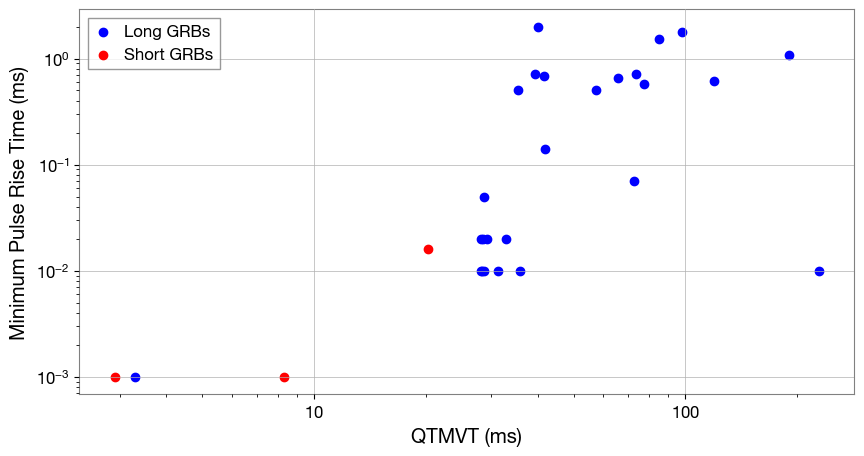

Just a note: I showed the few short GRBs that worked for this Q-transform method, but really this test is best for the long GRBs we currently have.


In [54]:
# Results
long_results = [a for a in results if a['type'] == 'long' and np.isfinite(a['minimum_rise_time'])]
short_results = [a for a in results if a['type'] == 'short' and np.isfinite(a['minimum_rise_time'])]
all_results = long_results + short_results

# QTMVT
long_qtmvt = np.array([a['QTMVT'] for a in long_results])
short_qtmvt = np.array([a['QTMVT'] for a in short_results])
all_qtmvt = np.array([a['QTMVT'] for a in all_results])

# Rise times
long_rise  = np.array([a['minimum_rise_time'] for a in long_results])
short_rise = np.array([a['minimum_rise_time'] for a in short_results])
all_rise = np.array([a['minimum_rise_time'] for a in all_results])

# T90
long_t90 = np.array([a['T90'] for a in long_results])

# Spearman test: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html
rho_long, p_long = spearmanr(long_qtmvt, long_rise)
rho_short, p_short = spearmanr(short_qtmvt, short_rise)
rho_all, p_all = spearmanr(all_qtmvt, all_rise)

# Run a spearman test for the correlation between
rho_t90_tau, p_t90_tau = spearmanr(long_qtmvt,long_t90)
rho_t90_rise, p_t90_rise = spearmanr(long_rise, long_t90)

# Partial correlation for long GRBs controlling for T90: https://pingouin-stats.org/generated/pingouin.partial_corr.html
df = pd.DataFrame({'MVT': long_qtmvt, 'rise_time': long_rise, 'T90': long_t90})
T90_exclusion = pg.partial_corr(data=df,x='MVT',y='rise_time',covar='T90',method='spearman')
rho_T90_exclusion = T90_exclusion['r'].values[0]
p_T90_exclusion = T90_exclusion['p_val'].values[0]

print(f"Long GRBs (N={len(long_qtmvt)}): rho = {rho_long:.4f},  p = {p_long:.4f}")
print(f"Short GRBs (N={len(short_qtmvt)}): rho = {rho_short:.4f}, p = {p_short:.4f}")
print(f"All GRBs(N={len(all_qtmvt)}): rho = {rho_all:.4f},  p = {p_all:.4f}")
print(f"MVT vs T90: rho ={rho_t90_tau:.4f}, p = {p_t90_tau:.4f}")
print(f"Rise time versus T90: rho = {rho_t90_rise:.4f}, p = {p_t90_rise:.4f}")
print(f"MVT vs rise time with T90 removed: rho = {rho_T90_exclusion:.4f}, p = {p_T90_exclusion:.4f}")

### Plot ###
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(long_qtmvt,  long_rise,  color='blue', label=f'Long GRBs')
ax.scatter(short_qtmvt, short_rise, color='red',  label=f'Short GRBs')
ax.set_xlabel('QTMVT (ms)')
ax.set_ylabel('Minimum Pulse Rise Time (ms)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
plt.show()

print("Just a note: I showed the few short GRBs that worked for this Q-transform method, but really this test is best for the long GRBs we currently have.")